# University Rankings Data Analysis

This notebook analyzes the **2018–2019 university rankings dataset** sourced from the Center for World University Rankings (CWUR). The analysis covers:

- **Data Cleaning & Preprocessing**: Handling missing values, type conversions, and column standardization
- **Exploratory Data Analysis**: Correlation analysis, scatter plots, box plots, and distribution charts
- **Geographic Visualization**: Geocoding universities and mapping their global distribution using Mapbox

## 1. Import Required Libraries

Import essential Python libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and file handling (`os`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

Load the university rankings dataset from the CSV file. The `unicode_escape` encoding is used to handle special characters in university names and locations.

In [2]:
data = pd.read_csv('src/eighteen_nineteen_university_datasets.csv', encoding = 'unicode_escape')
data


,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
0,1,Harvard University,USA,1,2,1,1,1,1,1,1,100.0
1,2,Stanford University,USA,2,10,3,2,10,4,3,2,96.7
2,3,Massachusetts Institute of Technology,USA,3,3,11,3,30,15,2,6,95.1
3,4,University of Cambridge,United Kingdom,1,5,19,6,12,8,6,19,94.0
4,5,University of Oxford,United Kingdom,2,9,25,10,9,5,7,4,93.2
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Aga Khan University,Pakistan,3,-,> 1000,-,> 1000,> 1000,464,673,69.8
996,997,University of Calcutta,India,17,353,716,296,798,966,> 1000,> 1000,69.8
997,998,K?chi University,Japan,56,-,> 1000,-,> 1000,> 1000,811,673,69.8
998,999,Soonchunhyang University,South Korea,35,-,> 1000,-,881,> 1000,> 1000,898,69.8


## 3. Initial Data Inspection

Use `df.info()` to examine the dataset's structure: column names, data types, non-null counts, and memory usage. This helps identify columns that need type conversion or cleaning.

In [3]:
df = pd.DataFrame(data)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   World Rank            1000 non-null   int64  
 1   Institution           1000 non-null   object 
 2   Location              1000 non-null   object 
 3   National Rank         1000 non-null   int64  
 4   Quality of Education  1000 non-null   object 
 5   Alumni Employment     1000 non-null   object 
 6   Quality of Faculty    1000 non-null   object 
 7   Research Output       1000 non-null   object 
 8   Quality Publications  1000 non-null   object 
 9   Influence             1000 non-null   object 
 10  Citations             1000 non-null   object 
 11  Score                 1000 non-null   float64
dtypes: float64(1), int64(2), object(9)
memory usage: 93.9+ KB


## 4. Custom Describe Function

Define a custom `describe()` function that provides a detailed data quality report for each column:

| Metric | Description |
|--------|-------------|
| **Variables** | Column names |
| **Count** | Total number of rows |
| **Unique** | Number of unique values |
| **Missing values** | Count of `NaN` entries |
| **Duplicated** | Number of duplicate rows in the dataset |
| **Not floatable** | Values that cannot be cast to `float` (data quality indicator) |

In [4]:
def describe(df):

    variables = []
    count = []
    unique = []
    missing_values = []
    duplicated = []
    not_floatable = []
    not_float_num = 0

    for col in df.columns:
        variables.append(col)
        count.append(len(df))
        unique.append(len(df[col].unique()))
        missing_values.append(df[col].isna().sum())
        duplicated.append(df.duplicated().sum())

           
        if df[col].dtype != 'float64':
            try:
                df[col].astype(float)
            except:
                for row in df[col]:
                    try:
                        float(row)
                    except:  
                        not_float_num += 1
        not_floatable.append(not_float_num)
        not_float_num = 0

    result = pd.DataFrame({
        'variables' : variables,
        'count' : count,
        'unique' : unique,
        'missing_values' : missing_values,
        'duplicated' : duplicated,
        'not_floatable' : not_floatable
    })

    return result





## 5. Data Cleaning — Column Names

Replace non-breaking space characters (`\xa0`) in column names with regular spaces, then run the custom `describe()` function to assess data quality before further cleaning.

In [5]:
df.columns = df.columns.str.replace('\xa0',' ')
df.columns.tolist()
describe(df)


,variables,count,unique,missing_values,duplicated,not_floatable
0,World Rank,1000,1000,0,0,0
1,Institution,1000,1000,0,0,1000
2,Location,1000,61,0,0,1000
3,National Rank,1000,213,0,0,0
4,Quality of Education,1000,404,0,0,597
5,Alumni Employment,1000,492,0,0,509
6,Quality of Faculty,1000,221,0,0,731
7,Research Output,1000,905,0,0,77
8,Quality Publications,1000,892,0,0,51
9,Influence,1000,830,0,0,171


## 6. Data Type Conversion

Define and apply a `to_float()` function to convert all numeric columns to `float64`:

| Original Value | Replacement | Reason |
|----------------|-------------|--------|
| `-` | `NaN` | Represents missing data |
| `> 1000` | `999` | Placeholder for ranks beyond 1000 |
| `< 1000` | `1001` | Placeholder for approximate ranks |

All columns except **Institution** and **Location** are cast to float.

In [6]:
def to_float(df):

    for item in df.columns:
        
        df[item] = df[item].replace('-',np.nan)
        df[item] = df[item].replace('> 1000', float(999))
        df[item] = df[item].replace('< 1000', float(1001))
        if item != 'Institution' and item != 'Location': 
            df[item] = df[item].astype(float)
            

In [7]:
    
to_float(df)
describe(df)

,variables,count,unique,missing_values,duplicated,not_floatable
0,World Rank,1000,1000,0,0,0
1,Institution,1000,1000,0,0,1000
2,Location,1000,61,0,0,1000
3,National Rank,1000,213,0,0,0
4,Quality of Education,1000,404,597,0,0
5,Alumni Employment,1000,492,0,0,0
6,Quality of Faculty,1000,221,731,0,0
7,Research Output,1000,905,0,0,0
8,Quality Publications,1000,892,0,0,0
9,Influence,1000,830,0,0,0


### Verify Data Types After Conversion

Run `df.info()` again to confirm all numeric columns have been successfully converted to `float64`.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   World Rank            1000 non-null   float64
 1   Institution           1000 non-null   object 
 2   Location              1000 non-null   object 
 3   National Rank         1000 non-null   float64
 4   Quality of Education  403 non-null    float64
 5   Alumni Employment     1000 non-null   float64
 6   Quality of Faculty    269 non-null    float64
 7   Research Output       1000 non-null   float64
 8   Quality Publications  1000 non-null   float64
 9   Influence             1000 non-null   float64
 10  Citations             1000 non-null   float64
 11  Score                 1000 non-null   float64
dtypes: float64(10), object(2)
memory usage: 93.9+ KB


## 7. Correlation Analysis

Compute and visualize the Pearson correlation matrix as a heatmap for all numeric columns. This reveals which ranking metrics are most strongly associated with overall university **Score**.

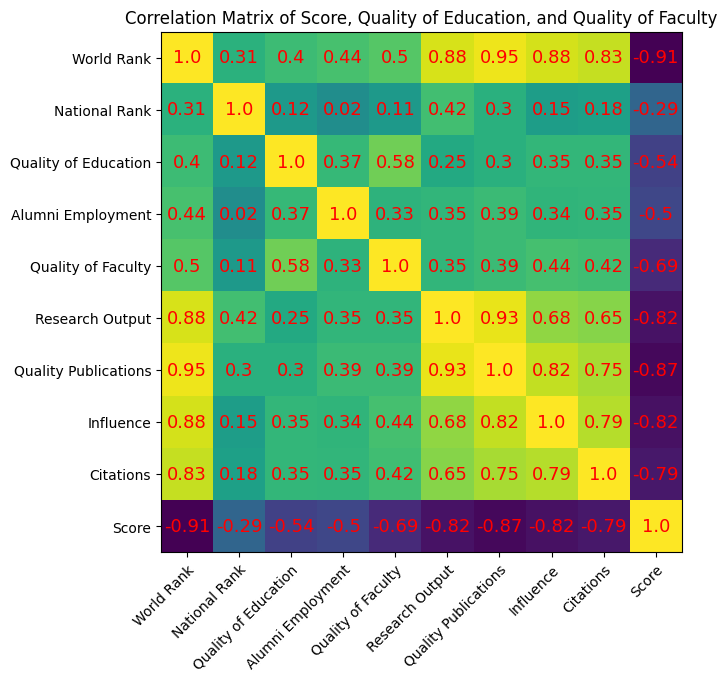

In [9]:

matrix_columns = df.columns.tolist()
matrix_columns.remove('Institution')
matrix_columns.remove('Location')
correlation_matrix = df[matrix_columns].corr().values


fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(correlation_matrix)

# Show all ticks and label them with the respective list entries
ax.set_xticks(range(len(matrix_columns)), labels=matrix_columns,
              rotation=45, ha="right", rotation_mode="anchor")
ax.set_yticks(range(len(matrix_columns)), labels=matrix_columns)

# Loop over data dimensions and create text annotations.
for i in range(len(matrix_columns)):
    for j in range(len(matrix_columns)):
        text = ax.text(j, i, (correlation_matrix[i, j]).round(2),
                       ha="center", va="center", color="red", fontsize=13)

ax.set_title("Correlation Matrix of Score, Quality of Education, and Quality of Faculty")
fig.tight_layout()
plt.show()

### Key Findings from the Correlation Matrix

The heatmap reveals **strong positive correlations** between university **Score** and the following metrics:

- **Quality of Faculty** — Faculty reputation and qualifications
- **Research Output** — Volume of published research
- **Quality Publications** — Publications in top-tier journals
- **Influence** — Research impact and reach
- **Citations** — Frequency of research being cited

> These factors are the strongest predictors of overall university ranking performance.

## 8. Statistical Summary

Display descriptive statistics (count, mean, std, min, 25%, 50%, 75%, max) for all numeric columns, rounded to 2 decimal places. This provides a quick overview of the central tendency and spread of each ranking metric.

In [10]:
df.describe(include='all').round(2)

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
count,1000.00,1000,1000,1000.00,403.00,1000.00,269.00,1000.00,1000.00,1000.00,1000.00,1000.00
unique,NaN,1000,61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Harvard University,USA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,500.50,NaN,NaN,40.02,323.41,725.51,144.82,508.30,502.90,528.81,500.94,75.03
std,288.82,NaN,NaN,49.23,194.08,342.87,88.64,299.83,292.68,321.92,308.52,4.67
min,1.00,NaN,NaN,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,69.80
25%,250.75,NaN,NaN,6.00,151.50,425.75,68.00,250.75,250.75,250.75,240.00,71.50
50%,500.50,NaN,NaN,21.00,321.00,999.00,140.00,500.50,500.50,502.50,460.00,73.75
75%,750.25,NaN,NaN,51.00,490.50,999.00,223.00,754.25,750.25,814.75,673.00,77.30


## 9. Exploratory Data Analysis

### 9.1 Scatter Plots — Score vs. Ranking Metrics

Plot each ranking metric against the overall **Score** to visually assess linear and non-linear relationships:

- Citations, Influence, Quality Publications, Research Output
- Alumni Employment, Quality of Faculty, Quality of Education

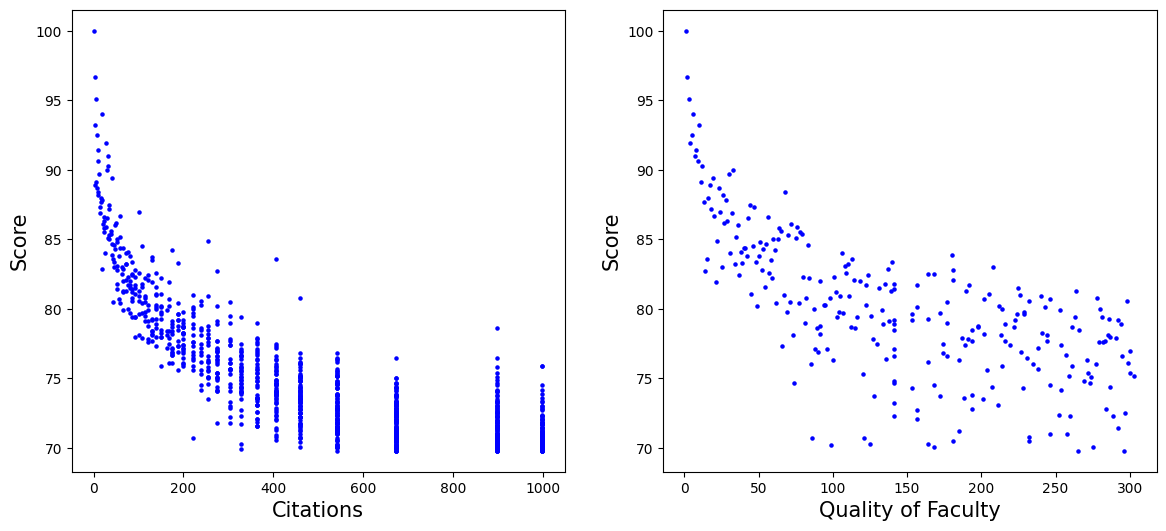

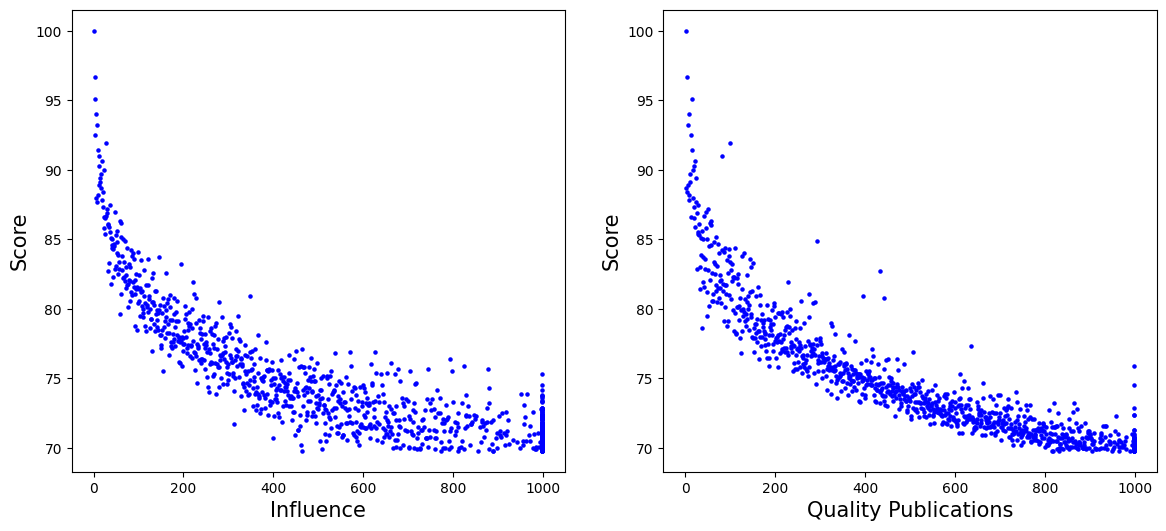

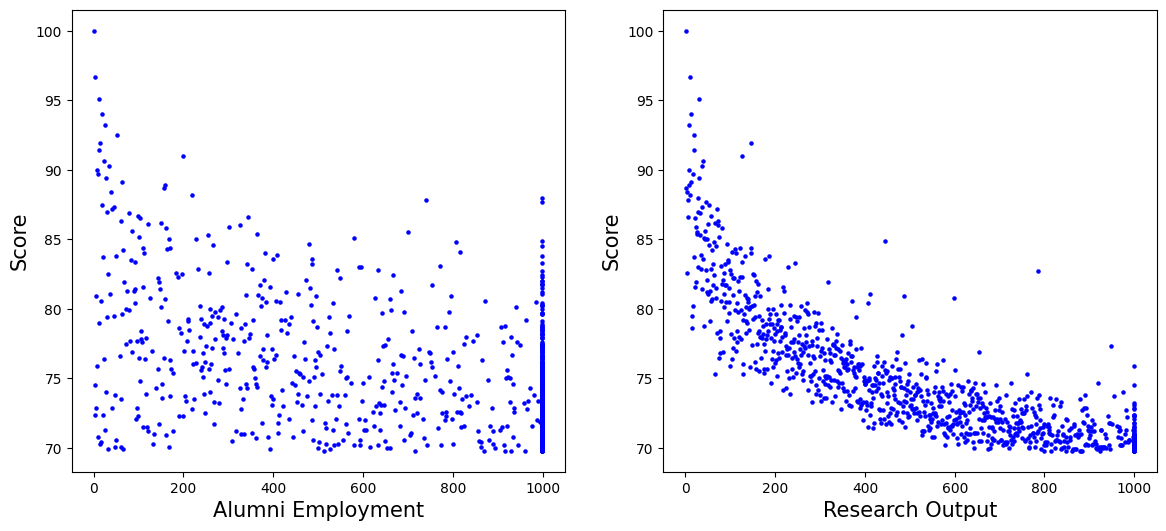

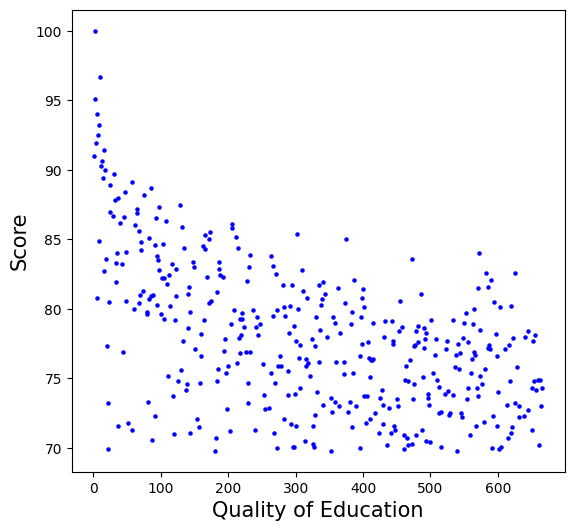

In [11]:

df_plot = df[[
                'Citations','Quality of Faculty','Influence','Quality Publications',
                'Alumni Employment','Research Output','Quality of Education'
              ]]

y = df['Score']

sizes = 5
colors = 'blue'

plt.figure(figsize=[14, 6]) 
i = 1

for cat in df_plot :
    
    plt.subplot(1,2,i)
    plt.scatter(df[cat], y, s=sizes, c=colors, )
    plt.xlabel(cat,fontsize = 15)
    plt.ylabel('Score',fontsize = 15)
    if i == 2 : 
        i = 0
        plt.show()
        plt.figure(figsize=[14, 6]) 
    i +=1

### 9.2 Box Plots — Outlier Detection

Box plots for each ranking metric to identify the distribution spread, median values, and potential outliers across all universities.

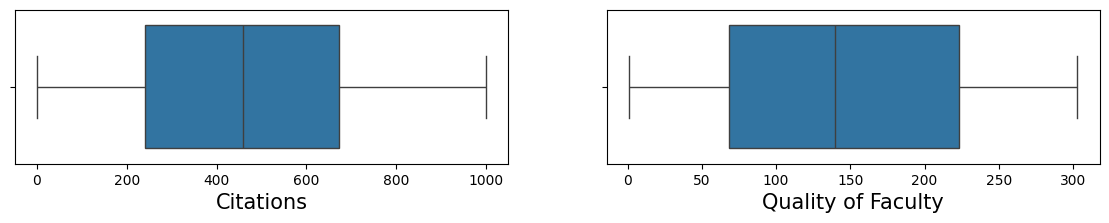

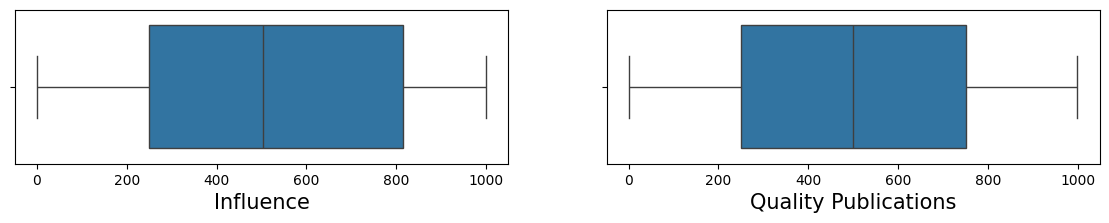

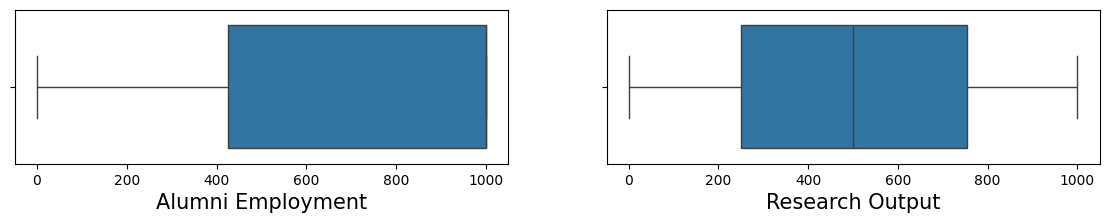

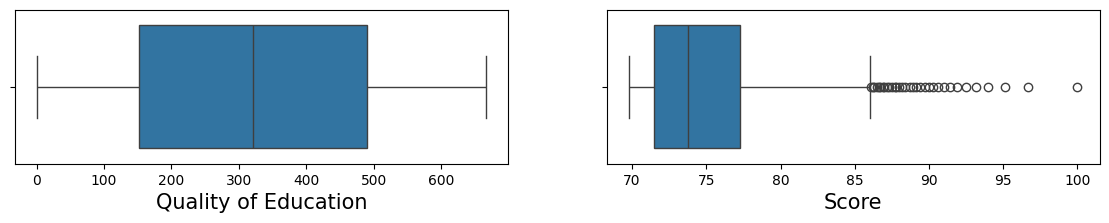

<Figure size 1400x200 with 0 Axes>

In [12]:

df_plot = df[[
                'Citations','Quality of Faculty','Influence','Quality Publications',
                'Alumni Employment','Research Output','Quality of Education','Score'
              ]]


plt.figure(figsize=[14, 2]) 
i = 1

for cat in df_plot :
    
    plt.subplot(1,2,i)
    sns.boxplot(data=df_plot,x=cat)
    plt.xlabel(cat,fontsize = 15)
    if i == 2 : 
        i = 0
        plt.show()
        plt.figure(figsize=[14, 2]) 
    i +=1

### 9.3 University Distribution by Country

A horizontal count plot showing the number of ranked universities per country, ordered by frequency. This highlights which countries dominate the global university rankings.

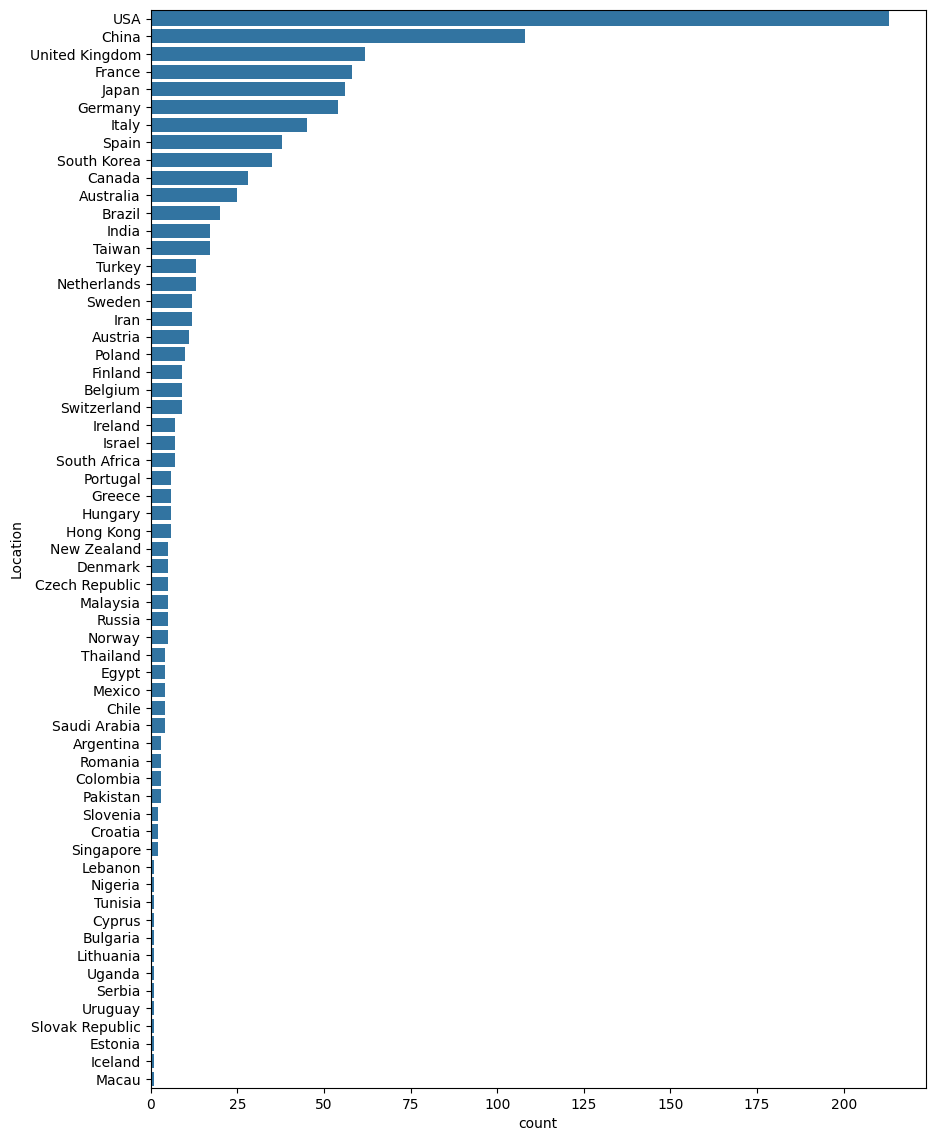

In [13]:
x = df['Location']
location_counts = x.value_counts().index
plt.figure(figsize=[10, 14]) 
sns.countplot(data=df_plot, y=x, order=location_counts, legend=False)
plt.show()

## 10. Geocoding Universities

Convert university locations to geographic coordinates (latitude & longitude) for map visualization:

- **Geocoder**: MapBox API via `geopy`
- **Rate limiting**: 50 ms delay between requests using `RateLimiter` to respect API limits
- **Query strategy**: Combines institution name + country for improved geocoding accuracy
- **Error handling**: Returns `NaN` for universities that fail to geocode
- **Cleanup**: Rows without valid coordinates are dropped from the mapping dataset

In [14]:
from geopy.geocoders import MapBox
import plotly.express as px
from geopy.extra.rate_limiter import RateLimiter
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()
MAPBOX_TOKEN = os.getenv('MAPBOX_TOKEN')

# Set Mapbox token globally for plotly
px.set_mapbox_access_token(MAPBOX_TOKEN)

geolocator = MapBox(api_key=MAPBOX_TOKEN)
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=0.05, max_retries=3)
coordinated_df = df.copy()

# Get latitude and longitude for each institution
# Use both Institution and Location for better accuracy
def get_coords(row):
    try:
        # Combine institution name with location for better geocoding
        query = f"{row['Institution']}, {row['Location']}"
        location = geocode(query)
        if location:
            return pd.Series([location.latitude, location.longitude])
        return pd.Series([np.nan, np.nan])
    except:
        return pd.Series([np.nan, np.nan])

coordinated_df[['Latitude', 'Longitude']] = coordinated_df.apply(get_coords, axis=1)

# Remove rows with missing coordinates
coordinated_df_clean = coordinated_df.dropna(subset=['Latitude', 'Longitude'])

print(f"Successfully geocoded: {len(coordinated_df_clean)} out of {len(coordinated_df)} institutions")



Successfully geocoded: 1000 out of 1000 institutions


## 11. Interactive Map Visualization (Initial)

Create an interactive Mapbox scatter plot to explore university distribution worldwide:


In [15]:
# Plot universities on map using Mapbox with color based on World Rank
fig = px.scatter_mapbox(coordinated_df_clean, 
                        lat="Latitude", 
                        lon="Longitude", 
                        hover_name="Institution",
                        hover_data={
                            "Location": True, 
                            "World Rank": True,
                            "Score": True,
                            "Latitude": ":.2f", 
                            "Longitude": ":.2f"
                        },
                        color="World Rank",  # Color by rank
                        size="Score",  # Size by score (optional)
                        size_max=5,  # Maximum circle size
                        color_continuous_scale="Inferno",  # Light to dark (lower rank = lighter)
                        zoom=1,
                        height=600)

fig.update_layout(
    title="World University Rankings - Geographic Distribution",
    title_x=0.5,  # Center the title
    mapbox_style="streets",
    margin={"r":0, "t":40, "l":0, "b":0},
    coloraxis_colorbar=dict(
        title="World Rank",
        orientation="h",
    )
)

fig.show()


## 12. Manual Coordinate Corrections

Some universities failed automatic geocoding. Their coordinates are manually supplied from known locations and applied using a dictionary lookup. This ensures complete coverage on the final map.

In [16]:
# Manual coordinates for universities that failed geocoding
manual_coords = {
    'university of la laguna': {'Latitude': 28.4872, 'Longitude': -16.3190},  # Tenerife, Spain
    'university of alcalá': {'Latitude': 40.4812, 'Longitude': -3.3626},  # Alcalá de Henares, Spain
    'insead': {'Latitude': 48.4081, 'Longitude': 2.7019},  # Fontainebleau, France
    'norwegian university of science and technology': {'Latitude': 63.4177, 'Longitude': 10.4010},  # Trondheim, Norway
    'catholic university of the sacred heart': {'Latitude': 45.4654, 'Longitude': 9.1859},  # Milan, Italy
    'sharif university of technology': {'Latitude': 35.7022, 'Longitude': 51.3508},  # Tehran, Iran
    'university of iceland': {'Latitude': 64.1395, 'Longitude': -21.9500}  # Reykjavik, Iceland
}

# Update coordinates for these universities
for institution, coords in manual_coords.items():
    mask = coordinated_df_clean['Institution'].str.lower() == institution
    coordinated_df_clean.loc[mask, 'Latitude'] = coords['Latitude']
    coordinated_df_clean.loc[mask, 'Longitude'] = coords['Longitude']

print(f"Updated coordinates for {len(manual_coords)} universities")


Updated coordinates for 7 universities


## 13. Final Map Visualization

Regenerate the interactive map with corrected coordinates included. This is the definitive geographic view of the world's top-ranked universities.

In [17]:
# Plot universities on map using Mapbox with color based on World Rank
fig = px.scatter_mapbox(coordinated_df_clean, 
                        lat="Latitude", 
                        lon="Longitude", 
                        hover_name="Institution",
                        hover_data={
                            "Location": True, 
                            "World Rank": True,
                            "Score": True,
                            "Latitude": ":.2f", 
                            "Longitude": ":.2f"
                        },
                        color="World Rank",  # Color by rank
                        size="Score",  # Size by score (optional)
                        size_max=5,  # Maximum circle size
                        color_continuous_scale="Inferno",  # Light to dark (lower rank = lighter)
                        zoom=1,
                        height=600)

fig.update_layout(
    title="World University Rankings - Geographic Distribution",
    title_x=0.5,  # Center the title
    mapbox_style="streets",
    margin={"r":0, "t":40, "l":0, "b":0},
    coloraxis_colorbar=dict(
        title="World Rank",
        orientation="h",
    )
)

fig.show()


---

## Summary of Key Findings

This analysis of the 2018–2019 university rankings dataset revealed:

1. **Strong Correlations**: University Score exhibits high positive correlations with Quality of Faculty, Research Output, Quality Publications, Influence, and Citations — confirming these as the primary drivers of university rankings.

2. **Data Quality**: The raw dataset required significant cleaning — special characters in column names, missing values encoded as `-`, and boundary strings (`> 1000`, `< 1000`) — all of which were standardized for proper statistical analysis.

3. **Geographic Patterns**: Geocoding and mapping universities globally revealed clustering of top-ranked institutions in North America, Western Europe, and East Asia, highlighting regional centers of academic excellence.

4. **Takeaway**: Research quality and faculty excellence consistently emerge as the strongest predictors of overall university ranking performance.